In [11]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import levene

In [12]:
API_KEY = "170265dcc664b1396cd1d6be03d32bc0"

In [13]:
def obtener_temperaturas(ciudad):
    url = f"https://api.openweathermap.org/data/2.5/forecast?q={ciudad}&appid={API_KEY}&units=metric"
    response = requests.get(url)
    data = response.json()

    temperaturas = []
    fechas = []

    for item in data['list']:
        temperaturas.append(item['main']['temp'])
        fechas.append(item['dt_txt'])

    df = pd.DataFrame({
        'Fecha': fechas,
        'Temperatura': temperaturas
    })

    return df

In [14]:
lima = obtener_temperaturas("Lima")
lima.head()

,Fecha,Temperatura
0,2025-12-18 06:00:00,20.50
1,2025-12-18 09:00:00,20.07
2,2025-12-18 12:00:00,19.69
3,2025-12-18 15:00:00,27.76
4,2025-12-18 18:00:00,31.44


In [15]:
trujillo = obtener_temperaturas("Trujillo")
trujillo.head()

,Fecha,Temperatura
0,2025-12-18 06:00:00,18.98
1,2025-12-18 09:00:00,18.93
2,2025-12-18 12:00:00,19.09
3,2025-12-18 15:00:00,22.16
4,2025-12-18 18:00:00,22.84


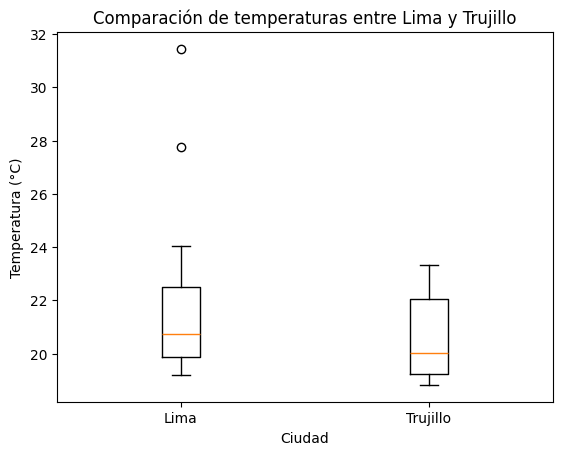

In [16]:
#Creamos un boxplot para obtener una comparación visual
plt.boxplot(
    [lima["Temperatura"], trujillo["Temperatura"]],
    tick_labels=["Lima", "Trujillo"]
);

plt.xlabel("Ciudad")
plt.ylabel("Temperatura (°C)")
plt.title("Comparación de temperaturas entre Lima y Trujillo")

plt.show()

In [18]:
# Prueba de Levene
from scipy.stats import levene

stat, p_value = levene(
    lima["Temperatura"],
    trujillo["Temperatura"]
)

print("Estadístico de Levene:", stat)
print("p-value:", p_value)

Estadístico de Levene: 0.3284000302644649
p-value: 0.5682511640594232


### Interpretación de la Prueba de Levene – Homogeneidad de varianzas

La prueba de Levene se utilizó para evaluar la homogeneidad de varianzas entre las
temperaturas de Lima y Trujillo.

El valor p obtenido es mayor que el nivel de significancia α = 0.05, por lo que
no se rechaza la hipótesis nula. Esto indica que no existen diferencias
estadísticamente significativas entre las varianzas de las temperaturas de ambas
ciudades.

Por lo tanto, se cumple el supuesto de homogeneidad de varianzas.
